In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate

from qiskit_aer import AerSimulator
from qiskit import transpile

import numpy as np
import random
import matplotlib.pyplot as plt
import itertools


Generating all codewords of $C_{2}$ from Parity check matrix $H_{X}$

In [2]:
def generate_C2_codewords_from_Parity_check_matrix(H_X):
    H_X = np.array(H_X)
    num_rows, num_cols = H_X.shape
    
    codewords = []
    
    for coeffs in itertools.product([0, 1], repeat=num_rows):
        codeword = np.dot(coeffs, H_X) % 2
        codewords.append(codeword)
        
    return codewords

Logical zero state $|0\rangle_{L}$ preparation from $C_{2}$ codewords

In [3]:
def logical_zero_state_preparation(codewords, N_data_qubits):
    dim = 2**N_data_qubits
    amps = np.zeros(dim, dtype=complex)
    for w in codewords:
        idx = sum(int(bit) << i for i, bit in enumerate(w))   # qiskit-convetion
        amps[idx] = 1 / np.sqrt(len(codewords))
    qr = QuantumRegister(N_data_qubits, 'd')
    qc = QuantumCircuit(qr)
    qc.prepare_state(amps, qc.qubits)
    return qc, qr

Inverse of Logical zero state preparation to revert back to $|0\rangle^{\otimes n}$

In [4]:
def logical_zero_state_reverse(qc_logical_zero_state):
    qc_logical_zero_state_rev = qc_logical_zero_state.copy()
    return qc_logical_zero_state_rev.inverse()

Applying Pauli error X, Z or Y on each data qubits with probability p

In [5]:
def apply_random_qubit_error(qc0, qr, N_data_qubits, p):
    qc = qc0.copy()
    sampled_error = []
    for i in range(N_data_qubits):
        if random.random() <= p:
            error_type = random.choice(['X', 'Y', 'Z'])
            sampled_error.append([i, error_type])
            if error_type == 'X':
                qc.x(qr[i])
            elif error_type == 'Y':
                qc.y(qr[i])
            elif error_type == 'Z':
                qc.z(qr[i])        
    return qc, sampled_error

Adding Syndrome measurement

In [25]:
def QHamming_Code_with_Syndrome(qc_encoded_with_error, qr, N_ancilla_qubits):
    a = QuantumRegister(N_ancilla_qubits, "a")
    c = ClassicalRegister(N_ancilla_qubits, "c")
    d = qr
    qc_ext = qc_encoded_with_error.copy()
    qc_ext.add_register(a)
    qc_ext.add_register(c)

    #Syndrome Measurements
    # S1 = IIIIIIIXXXXXXXX
    qc_ext.h(a[0])
    qc_ext.cx(a[0], d[7])
    qc_ext.cx(a[0], d[8])
    qc_ext.cx(a[0], d[9])
    qc_ext.cx(a[0], d[10])
    qc_ext.cx(a[0], d[11])
    qc_ext.cx(a[0], d[12])
    qc_ext.cx(a[0], d[13])
    qc_ext.cx(a[0], d[14])
    qc_ext.h(a[0])

    # S2 = IIIXXXXIIIIXXXX
    qc_ext.h(a[1])
    qc_ext.cx(a[1], d[3])
    qc_ext.cx(a[1], d[4])
    qc_ext.cx(a[1], d[5])
    qc_ext.cx(a[1], d[6])
    qc_ext.cx(a[1], d[11])
    qc_ext.cx(a[1], d[12])
    qc_ext.cx(a[1], d[13])
    qc_ext.cx(a[1], d[14])
    qc_ext.h(a[1])

    # S3 = IXXIIXXIIXXIIXX
    qc_ext.h(a[2])
    qc_ext.cx(a[2], d[1])
    qc_ext.cx(a[2], d[2])
    qc_ext.cx(a[2], d[5])
    qc_ext.cx(a[2], d[6])
    qc_ext.cx(a[2], d[9])
    qc_ext.cx(a[2], d[10])
    qc_ext.cx(a[2], d[13])
    qc_ext.cx(a[2], d[14])
    qc_ext.h(a[2])
   
    # S4 = XIXIXIXIXIXIXIX
    qc_ext.h(a[3])
    qc_ext.cx(a[3], d[0])
    qc_ext.cx(a[3], d[2])
    qc_ext.cx(a[3], d[4])
    qc_ext.cx(a[3], d[6])
    qc_ext.cx(a[3], d[8])
    qc_ext.cx(a[3], d[10])
    qc_ext.cx(a[3], d[12])
    qc_ext.cx(a[3], d[14])
    qc_ext.h(a[3])

    # S5 = IIIIIIIZZZZZZZZ
    qc_ext.h(a[4])
    qc_ext.cz(a[4], d[7])
    qc_ext.cz(a[4], d[8])
    qc_ext.cz(a[4], d[9])
    qc_ext.cz(a[4], d[10])
    qc_ext.cz(a[4], d[11])
    qc_ext.cz(a[4], d[12])
    qc_ext.cz(a[4], d[13])
    qc_ext.cz(a[4], d[14])
    qc_ext.h(a[4])

    # S6 = IIIZZZZIIIIZZZZ
    qc_ext.h(a[5])
    qc_ext.cz(a[5], d[3])
    qc_ext.cz(a[5], d[4])
    qc_ext.cz(a[5], d[5])
    qc_ext.cz(a[5], d[6])
    qc_ext.cz(a[5], d[11])
    qc_ext.cz(a[5], d[12])
    qc_ext.cz(a[5], d[13])
    qc_ext.cz(a[5], d[14])
    qc_ext.h(a[5])

    # S7 = IZZIIZZIIZZIIZZ
    qc_ext.h(a[6])
    qc_ext.cz(a[6], d[1])
    qc_ext.cz(a[6], d[2])
    qc_ext.cz(a[6], d[5])
    qc_ext.cz(a[6], d[6])
    qc_ext.cz(a[6], d[9])
    qc_ext.cz(a[6], d[10])
    qc_ext.cz(a[6], d[13])
    qc_ext.cz(a[6], d[14])
    qc_ext.h(a[6])

    # S8 = ZIZIZIZIZIZIZIZ
    qc_ext.h(a[7])
    qc_ext.cz(a[7], d[0])
    qc_ext.cz(a[7], d[2])
    qc_ext.cz(a[7], d[4])
    qc_ext.cz(a[7], d[6])
    qc_ext.cz(a[7], d[8])
    qc_ext.cz(a[7], d[10])
    qc_ext.cz(a[7], d[12])
    qc_ext.cz(a[7], d[14])
    qc_ext.h(a[7])

    qc_ext.barrier()
    qc_ext.measure(a, c)

    syndrome_set = c

    return qc_ext, syndrome_set

Building Syndrome lookup table from Parity check matrix $H$

In [7]:
def build_QHamming_syndrome_table(H, X_stab_len):
    n = len(H[0])
    x_stab = ''.join(['0' for i in range(X_stab_len)])
    table = {}
    for q in range(n):
        col = [H[r][q] for r in range(len(H))]      # [row1,row2,row3,row4]
        s = ''.join(str(b) for b in col[::-1])      # [row4,row3,row2,row1]

        table[s + x_stab] = (q, 'X')
        table[x_stab + s] = (q, 'Z')
        table[s + s]      = (q, 'Y')

    return table

Recovery Operation based on Syndrome outcome

In [26]:
def QHamming_recovery_operation_final(qc_encoded_with_error_in, qr, QHamming_syndrome_table, syndrome_set):
    qc_encoded_with_error = qc_encoded_with_error_in.copy()
    for s_bits, (q_index, pauli) in QHamming_syndrome_table.items():
        s_int = int(s_bits, 2)
        with qc_encoded_with_error.if_test((syndrome_set, s_int)):
            if pauli == "X":
                qc_encoded_with_error.x(qr[q_index])
            elif pauli == "Y":
                qc_encoded_with_error.y(qr[q_index])
            elif pauli == "Z":
                qc_encoded_with_error.z(qr[q_index])
    return qc_encoded_with_error

Measuring data qubits to determine the success probability

In [ ]:
def QHamming_data_measure(qc_recovery_dec, qr, N_data_qubits):
    qc_recovery_dec_cir = qc_recovery_dec.copy()
    cd = ClassicalRegister(N_data_qubits, 'cd')
    qc_recovery_dec_cir.add_register(cd)
    qc_recovery_dec_cir.barrier()
    qc_recovery_dec_cir.measure(qr, cd)
    return qc_recovery_dec_cir

Logical zero state preparation -> Random Pauli error applied -> Syndrome measurement circuit -> Recovery operation based on Syndrome outcome -> Reverting back to $|0\rangle^{\otimes n}$ state -> Measuring data qubits

In [19]:
def qc_QHamming_QEC_encoded(H_X, N_data_qubits):
    codewords = generate_C2_codewords_from_Parity_check_matrix(H_X)
    qc_logical_zero_state, qr = logical_zero_state_preparation(codewords, N_data_qubits)
    return qc_logical_zero_state, qr

def qc_QHamming_QEC_recovery(qc_logical_zero_state, qr, N_data_qubits, N_ancilla_qubits, p, QHamming_syndrome_table):
    qc_QHamming_encoded_with_error, qc_QHamming_err_type = apply_random_qubit_error(qc_logical_zero_state, qr, N_data_qubits, p)
    qc_QHamming_with_syndrome_measurement, syndrome_set = QHamming_Code_with_Syndrome(qc_QHamming_encoded_with_error, qr, N_ancilla_qubits)
    qc_QHamming_recovery = QHamming_recovery_operation_final(qc_QHamming_with_syndrome_measurement, qr, QHamming_syndrome_table, syndrome_set)
    qc_logical_state_reverse = logical_zero_state_reverse(qc_logical_zero_state)
    qc_QHamming_recovery_dec = qc_QHamming_recovery.compose(qc_logical_state_reverse, inplace = False)
    qc_QHamming_recovery_dec_mes = QHamming_data_measure(qc_QHamming_recovery_dec, qr, N_data_qubits)
    return qc_QHamming_recovery_dec_mes

Determining success probability

In [20]:
def estimate_success_probability_QHamming(qc_logical_zero_state, qr, p, trials, 
                                 N_data_qubits, N_ancilla_qubits, QHamming_syndrome_table):
    sim = AerSimulator(method="matrix_product_state")
    target = "000000000000000"
    success = 0
    for i in range(trials):
        qc_recovery_dec_mes = qc_QHamming_QEC_recovery(qc_logical_zero_state, qr, 
                                                N_data_qubits, N_ancilla_qubits, p, QHamming_syndrome_table)

        qc_run = transpile(qc_recovery_dec_mes, sim, optimization_level = 1)
        counts = sim.run(qc_run, shots=1).result().get_counts()
        key = next(iter(counts))
        readout = key.split()[0]
        if readout == target:
            success += 1
    return success/trials, success    

In [11]:
# [[15,7,3]]
H_X = [
    [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1],
    [0,0,0,1,1,1,1,0,0,0,0,1,1,1,1],
    [0,1,1,0,0,1,1,0,0,1,1,0,0,1,1],
    [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1]
]

all_C2_codewords = generate_C2_codewords_from_Parity_check_matrix(H_X)

print(f"Total codewords in C2: {len(all_C2_codewords)}")

Total codewords in C2: 16


Verifying Logical zero state preparation and Syndrome measurement for no error

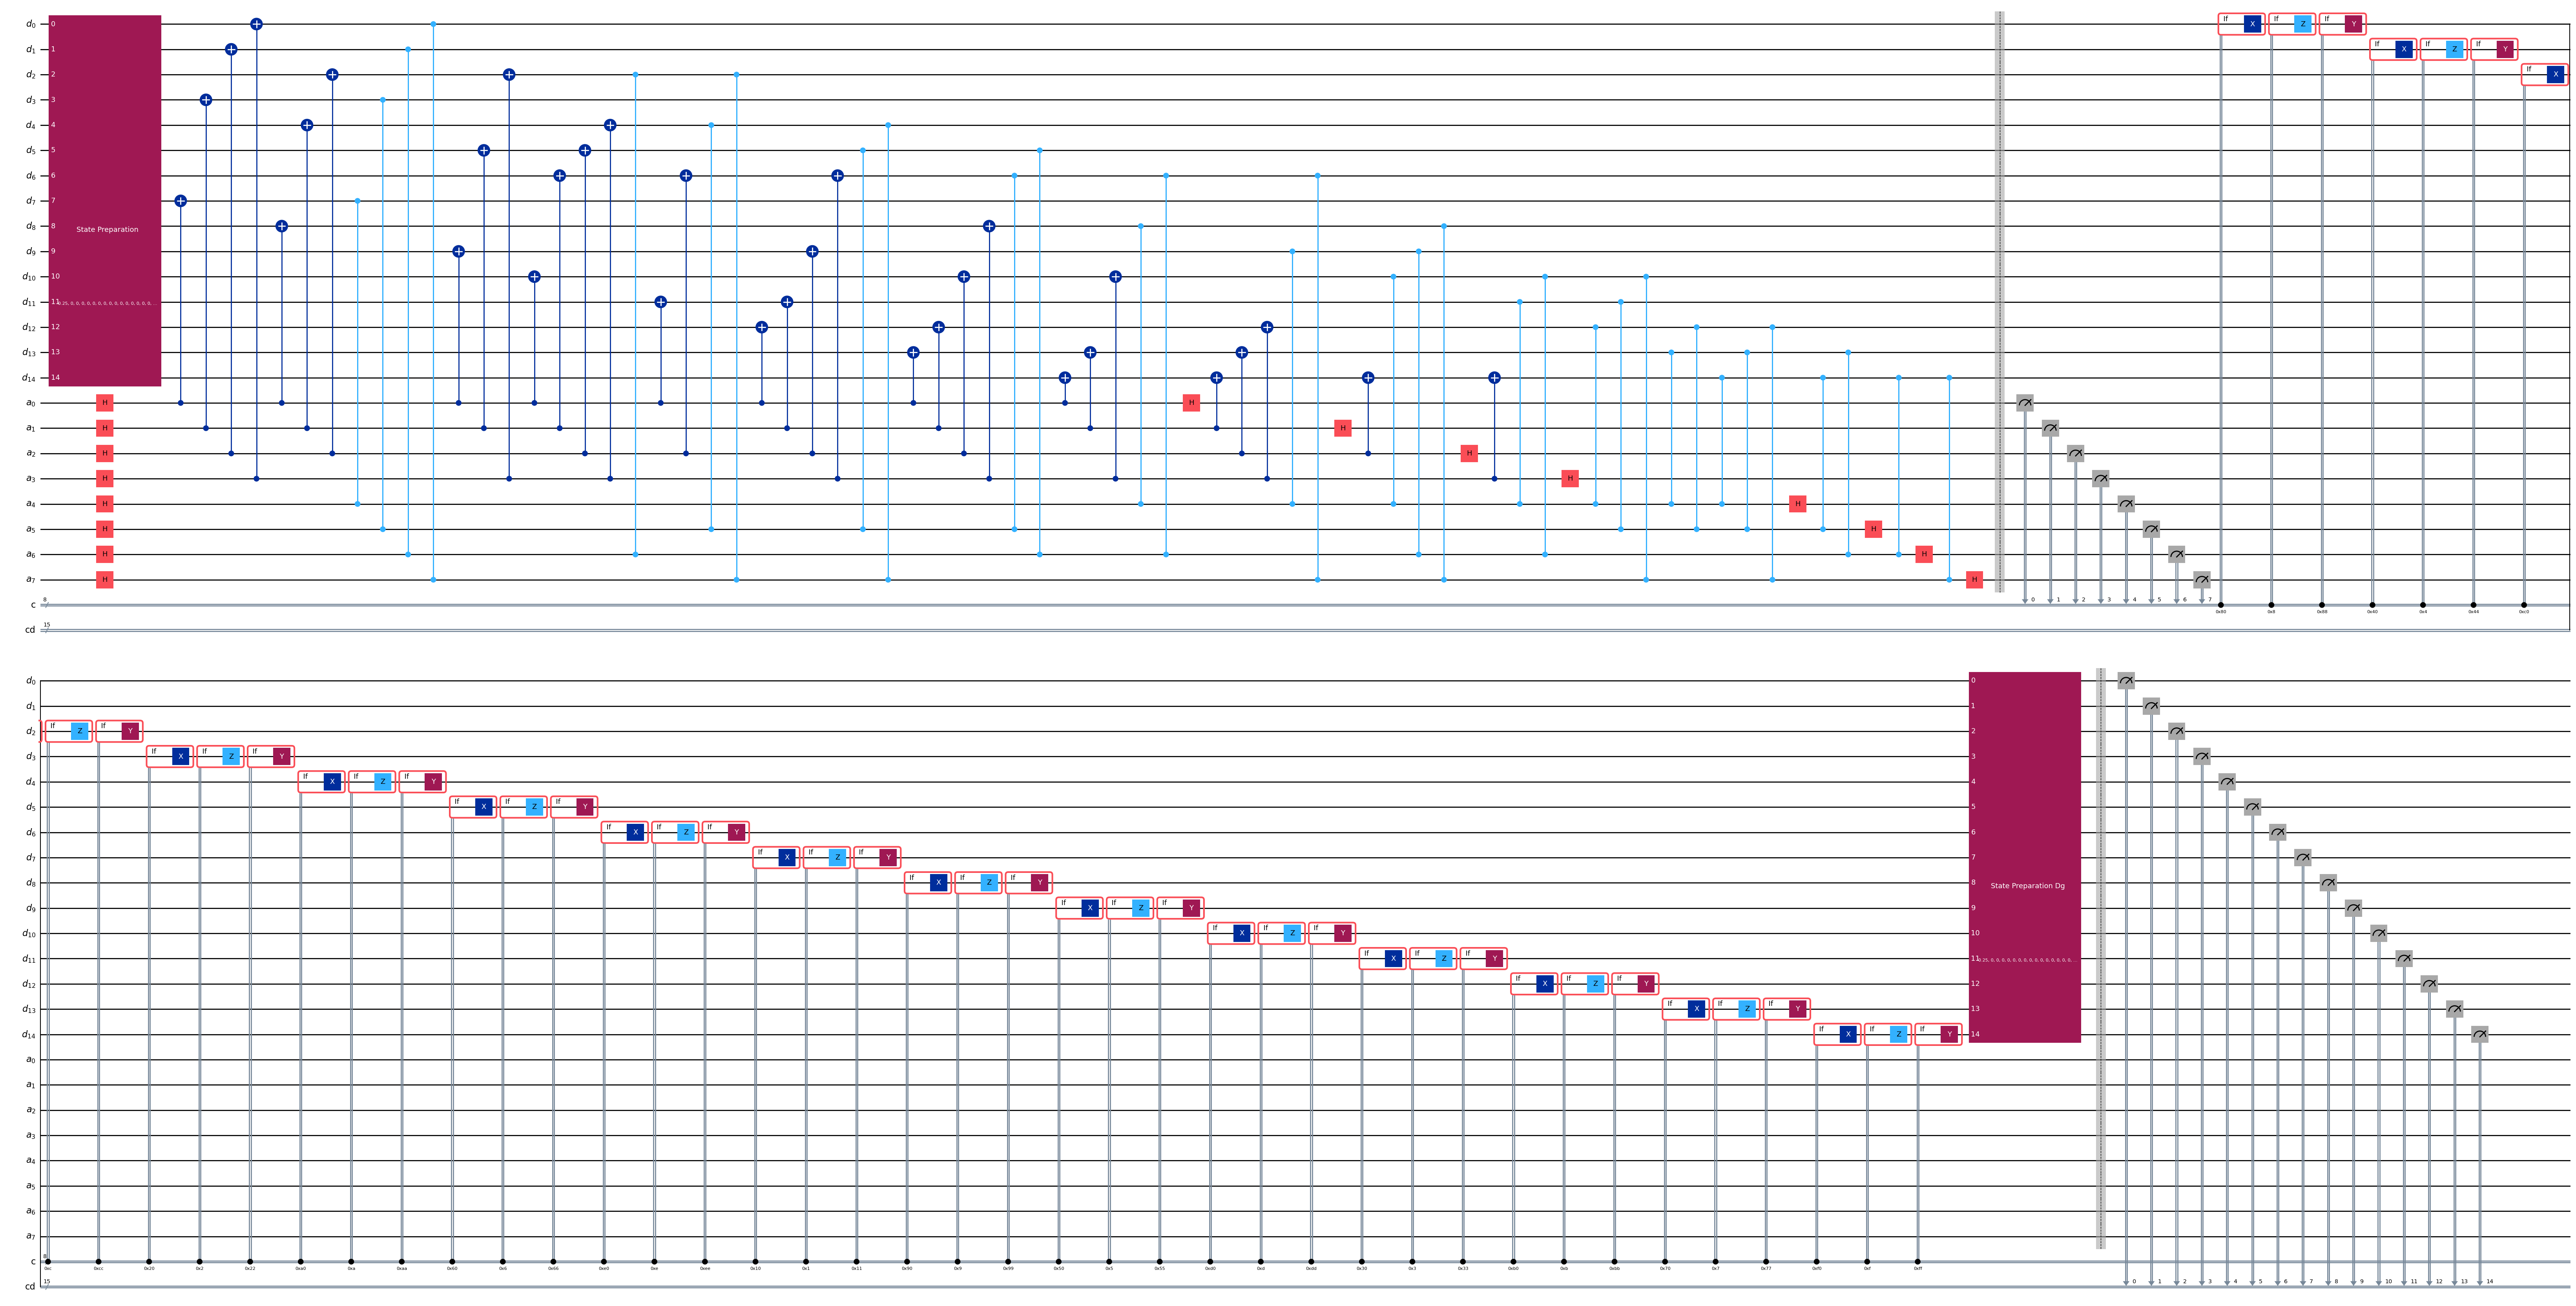

In [12]:
p = 0.0
N_data_qubits = 15
N_ancilla_qubits = 8
qc_logical_zero_state, qr = logical_zero_state_preparation(all_C2_codewords, N_data_qubits)
qc_QHamming_encoded_with_error, qc_QHamming_err_type = apply_random_qubit_error(qc_logical_zero_state, qr, N_data_qubits, p)
qc_QHamming_with_syndrome_measurement, syndrome_set = QHamming_Code_with_Syndrome(qc_QHamming_encoded_with_error, qr, N_ancilla_qubits)
QHamming_syndrome_table = build_QHamming_syndrome_table(H_X, 4)
qc_QHamming_recovery = QHamming_recovery_operation_final(qc_QHamming_with_syndrome_measurement, qr, QHamming_syndrome_table, syndrome_set)
qc_logical_state_reverse = logical_zero_state_reverse(qc_logical_zero_state)
qc_QHamming_recovery_dec = qc_QHamming_recovery.compose(qc_logical_state_reverse, inplace = True)
qc_QHamming_recovery_dec_mes = QHamming_data_measure(qc_QHamming_recovery, qr, N_data_qubits)
qc_QHamming_recovery_dec_mes.draw('mpl', fold = 100)

In [14]:
sim = AerSimulator(method="matrix_product_state")
qc_run = transpile(qc_QHamming_recovery_dec_mes, sim, optimization_level = 1)
counts = sim.run(qc_run, shots=1).result().get_counts()

print(counts)

{'000000000000000 00000000': 1}


In [43]:
qc_run_ancilla = transpile(qc_QHamming_with_syndrome_measurement, sim)
counts_ancilla = sim.run(qc_run_ancilla, shots=1).result().get_counts()

print(counts_ancilla)

{'00000000': 1}


Success probability vs error probability

In [21]:
# [[15,7,3]]
H_X = [
    [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1],
    [0,0,0,1,1,1,1,0,0,0,0,1,1,1,1],
    [0,1,1,0,0,1,1,0,0,1,1,0,0,1,1],
    [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1]
]

N_data_qubits = 15
N_ancilla_qubits = 8

qc_logical_zero_state, qr = qc_QHamming_QEC_encoded(H_X, N_data_qubits)
qc_logical_zero_state_copy = qc_logical_zero_state.copy()
QHamming_syndrome_table = build_QHamming_syndrome_table(H_X, 4)

trials = 10

p_values = np.linspace(0, 0.9, 10)
success_prob_p = []
success_p = []
for i in range(len(p_values)):
    p = p_values[i]
    success_prob, success = estimate_success_probability_QHamming(qc_logical_zero_state_copy, qr, p, trials, 
                                 N_data_qubits, N_ancilla_qubits, QHamming_syndrome_table)
    success_prob_p.append(success_prob)
    success_p.append(success)

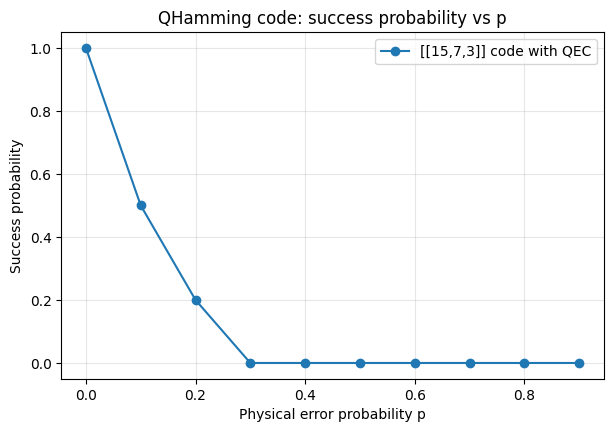

In [22]:
plt.figure(figsize=(7, 4.5))
plt.plot(p_values, success_prob_p, "o-", label="[[15,7,3]] code with QEC")
plt.xlabel("Physical error probability p")
plt.ylabel("Success probability")
plt.title("QHamming code: success probability vs p")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()